In [1]:
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape)
print(y_train[0])

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# 60000 images, each one with 28x28 pixels
# The first image is a handwritten digit that represents the number 5

In [ ]:
# Next, we have to apply a method called normalization. Neural networks undestands in data in a better way when the
# numbers are in a small scale, such as 0 to 1. In this dataset, each pixel from the images comes with the values 0 to 255 (0 equals to black,
# 255 equals to white). So, we have to deal with this:

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
print(x_train.min(), x_train.max())

0.0 1.0


In [ ]:
# Now, we have to split the data into parts:
# Train/Validation/Test Split
# - Training data: examples the model learns from, adjusting its
#   parameters based on them.
# - Validation data: held out during training and used to check the model's
#  progress. The model never learns from it directly, it's
#  used to catch overfitting (when the model memorizes training examples
#  instead of learning general patterns) and to guide adjustments.
# - Test data: never seen during training or validation. Used only once,
#  at the end, to get an unbiased measure of real performance.

# Validation and test are kept separate because repeatedly tuning the model
# based on test results would indirectly let it "learn" the test set, making
# that final measure unreliable.

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1)
print(x_train.shape, x_val.shape, x_test.shape)

(54000, 28, 28) (6000, 28, 28) (10000, 28, 28)


In [ ]:
# Now, we need to create a neural network, more precisely, one in sequential layers. Each layer receives a result from the previous layer and move on to the next:

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Flatten(input_shape=(28, 28)): takes the image—a 28x28 grid—and "flattens" it into a single list of 784 numbers (28 times 28)
# Simple neural networks like this one don't understand images as grids, they only process lists of numbers.

# Dense(128, activation='relu'): a layer of 128 "neurons," each learning to recognize a specific pattern in the data.
# "relu" is a mathematical function that helps the network learn non-linear patterns (without it,
# the network would only be able to learn overly simple relationships).

# Dense(10, activation='softmax'): the final layer, with 10 outputs—one for each possible digit (0 through 9).
# Softmax converts these 10 outputs into probabilities that sum to 100% (e.g., "an 85% chance it's a 5, a 10% chance it's a 6...").

In [ ]:
# Now, we have 101.770 parameters (128 neurons x 784 inputs = 100.352 weights + 128 biases = 100.480 parameters + 1.290 = 101.770 trainable parameters)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# optimizer='adam': the optimization algorithm used to update the model's trainable parameters during training.
# Adam adjusts the weights and biases based on the error calculated by the loss function,
# helping the model gradually improve its predictions.

# The training process works approximately like this:
# image → model makes a prediction → prediction is compared to the correct answer
# → the error is calculated → the optimizer adjusts the parameters → the model tries again.


# loss='sparse_categorical_crossentropy': the loss function used to measure how wrong the model's prediction is.
# It compares the model's predicted probabilities with the correct class.
# A lower loss generally means that the model's predictions are closer to the correct answers.

# For example, if the correct answer is 7, the model might predict:
# 0 → 0.01
# 1 → 0.02
# 2 → 0.01
# 3 → 0.03
# 4 → 0.02
# 5 → 0.01
# 6 → 0.05
# 7 → 0.80
# 8 → 0.03
# 9 → 0.02
# This is a good prediction because the model assigns a high probability to the correct class (7).

# If the model assigns a high probability to the wrong class instead,
# the loss will be higher, indicating that the prediction was worse.


# metrics=['accuracy']: tells the model to track accuracy while training and evaluating.
# Accuracy represents the proportion of predictions that the model classified correctly.

# For example:
# accuracy = 0.92
# This means that the model correctly classified approximately 92% of the images.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val)
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9224 - loss: 0.2718 - val_accuracy: 0.9578 - val_loss: 0.1471
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9640 - loss: 0.1208 - val_accuracy: 0.9688 - val_loss: 0.1060
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9752 - loss: 0.0830 - val_accuracy: 0.9705 - val_loss: 0.0957
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9814 - loss: 0.0621 - val_accuracy: 0.9742 - val_loss: 0.0909
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9847 - loss: 0.0478 - val_accuracy: 0.9767 - val_loss: 0.0826


In [ ]:
# 'history = ...' will generate information such as loss, accuracy, val_loss, val_accuracy

# model.fit(): trains the neural network using the training data.
# During training, the model makes predictions, calculates the loss,
# and updates its trainable parameters using the optimizer.

# x_train: the training images.
# y_train: the correct labels corresponding to those images.

# epochs=5: the model will go through the entire training dataset 5 times.
# Each complete pass through the training dataset is called an epoch.

# validation_data=(x_val, y_val): after each epoch, the model is evaluated
# on the validation dataset to measure how well it performs on data it did not train on.

In [ ]:
# The accuracy (and validation) is only getting higher with more epochs, and the loss is only getting lower

In [ ]:
# Now, we need to know the model behaves in the test set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print(f'Test Loss: ', test_loss)
print(f'Test Accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0729
Test Loss:  0.07291767746210098
Test Accuracy: 0.977400004863739


In [ ]:
# The model correctly classified approximately 97.74% of the unseen test images.
# Because the test set was kept separate from training and validation,
# this provides an estimate of how well the trained model generalizes to unseen data.

In [ ]:
# But how the model is doing wrong predictions?

In [ ]:
predictions = model.predict(x_test)
print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)


In [ ]:
# model.predict(): generates predictions for the input images.
# For each image, the model outputs 10 probability values,
# one for each possible digit (0 through 9).

# predictions.shape should be (10000, 10): 10,000 test images × 10 possible classes

#                  10 classes
#         ┌────────────────────────┐
# Imagem 1│ 0.01 0.00 0.02 ... 0.92│
# Imagem 2│ 0.00 0.03 0.01 ... 0.01│
# Imagem 3│ 0.98 0.00 0.00 ... 0.00│
#    ...  │           ...          │
# Imagem  │           ...          │
# 10000   │ 0.01 0.02 0.01 ... 0.03│
#         └────────────────────────┘

# All of this happens because of (keras.layers.Dense(10, activation='softmax')

In [ ]:
# We need to transform the probabilities into predictions

In [ ]:
predicted_labels = predictions.argmax(axis=1)

print(predicted_labels[:10])
print(y_test[:10])

[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


In [ ]:
# predictions.argmax(axis=1): takes the class with the highest probability for each image.
# predicted_labels[:10]: shows the first 10 predictions
# y_test[:10]: shows the correct responses for these 10 images

In [ ]:
# For the 10 first images, all the 10 predictions were right

In [ ]:
# Now, lets visualize these predictions:

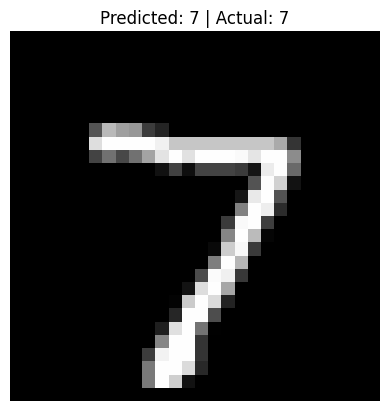

In [ ]:
import matplotlib.pyplot as plt

index = 0

plt.imshow(x_test[index], cmap='gray')
plt.title(
    f'Predicted: {predicted_labels[index]} | Actual: {y_test[index]}'
)
plt.axis('off')
plt.show()

In [ ]:
# index = 0: selects which image from the test dataset we want to visualize.
# Python uses zero-based indexing, so index 0 refers to the first image.

# plt.imshow(): displays an image.
# x_test[index] selects the image at the specified index from the test dataset.
# cmap='gray' displays the image using a grayscale color map.

# plt.title(): adds a title above the image.

# plt.axis('off'): hides the x-axis and y-axis from the visualization.
# The axes are not useful for this visualization, so we hide them to make
# the image easier to inspect.

# plt.show(): displays the completed visualization.
# The parentheses () are important because they call/execute the function.

In [ ]:
import numpy as np

wrong_indices = np.where(predicted_labels != y_test)[0]

print(f'Number of incorrect predictions:  {len(wrong_indices)}')
print(f'First incorrect index: {wrong_indices[0]}')

Number of incorrect predictions:  226
First incorrect index: 151


In [ ]:
# predicted_labels != y_test: compares the model's predictions with the correct labels.
# It produces True where the model made a mistake and False where it was correct.

#For example:
# predicted_labels:  [7, 2, 3, 4]
# y_test:            [7, 2, 8, 4]
# comparison:        [False, False, True, False]

# np.where(): finds the positions (indices) where the condition is True.
# In this case, it finds the indices of the images that the model classified incorrectly.

# For example:
# False, False, True, False]
# [2]

# len(wrong_indices): counts how many incorrect predictions were found.
# print(): displays the result.
# The f-string inserts the number directly into the text.

In [ ]:
# To visualize an example of error:

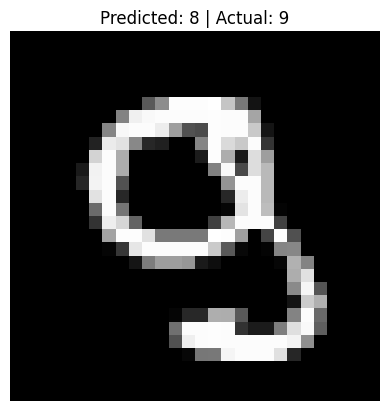

In [ ]:
import matplotlib.pyplot as plt

index = 151 #index = wrong_indices[0] = 151

plt.imshow(x_test[index], cmap='gray')
plt.title(
    f'Predicted: {predicted_labels[index]} | Actual: {y_test[index]}'
)
plt.axis('off')
plt.show()